# 전처리 → 자체 GT 만들기 (SENSE)

RSS를 GT로 쓰지 않고 아래 과정으로 **자체 GT(SENSE 결합)** 를 만든다.

1. **kx(readout, 640) 방향 1D Fourier → 위아래(readout) crop 640→320 → 다시 k-space**  *(readout oversampling만 제거)*
2. **phase(ky, 368) 의 0이 아닌 부분만 crop**  *(zero-padding 36열 제거 → 332, 실제 데이터는 보존)*
3. 320×332 fully-sampled k-space를 **recon(ESPIRiT 감도맵 → SENSE 결합) → 이게 GT**

> 핵심: phase를 320으로 자르지 않고 **획득 라인 전부(332) 유지**. 공식 RSS(320×320)와는 별개 GT.
> 감도맵은 **full readout에서 추정 후 crop**해 FOV-가장자리 검은 띠 artifact를 피한다.

In [1]:
import os, sys, glob
sys.path.insert(0, '/home/sonwonjun/research/MRRecon/code')
import numpy as np, h5py
import matplotlib.pyplot as plt
from MakeDataset import espirit_sens_maps               # sets up BART
from mrrecon.data.transforms import sense_combine_np, rss_np

RAW = '/mnt/d/research/MRRecon/multicoil_val'
f = sorted(glob.glob(RAW + '/*.h5'))[0]
with h5py.File(f, 'r') as h:
    s = h['kspace'].shape[0] // 2
    kraw = h['kspace'][s]                                # (15,640,368) raw multi-coil
    rss_official = h['reconstruction_rss'][s]            # (320,320) official GT (참고용)
print('raw k-space', kraw.shape)

# 1-D FFT helpers along readout axis (-2)
def klog(x): return np.log(np.abs(x) + 1e-9)   # unified log-magnitude display
def ifft1_ro(x): return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(x,axes=-2),axis=-2,norm='ortho'),axes=-2)
def fft1_ro(x):  return np.fft.fftshift(np.fft.fft (np.fft.ifftshift(x,axes=-2),axis=-2,norm='ortho'),axes=-2)

raw k-space (15, 640, 368)


## 1단계 — kx(readout) 1D Fourier → 위아래 crop 640→320 → k-space
readout만 1D IFFT(영상) → 위아래 640→320 자름 → 1D FFT(다시 k-space). **phase는 그대로.**

step1: (15, 320, 368)


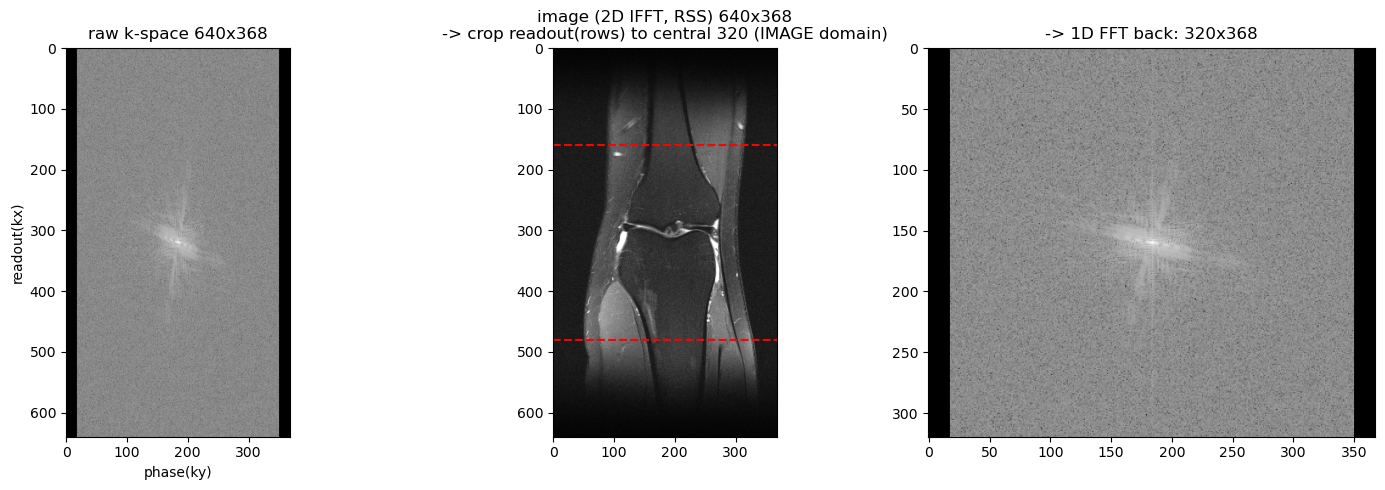

In [2]:
img_ro = ifft1_ro(kraw)                                 # (15,640,368) readout image, phase still k-space
top = (640 - 320) // 2
k1 = fft1_ro(img_ro[:, top:top+320, :])                # (15,320,368)
print('step1:', k1.shape)
fig, ax = plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(klog(kraw[7]), cmap='gray', aspect='equal'); ax[0].set_title('raw k-space 640x368'); ax[0].set_ylabel('readout(kx)'); ax[0].set_xlabel('phase(ky)')
full_img = rss_np(kraw)                                 # full 2D image (RSS) 640x368
ax[1].imshow(full_img, cmap='gray', aspect='equal', vmax=0.6*full_img.max())
ax[1].axhline(top,color='r',ls='--'); ax[1].axhline(top+320,color='r',ls='--')
ax[1].set_title('image (2D IFFT, RSS) 640x368\n-> crop readout(rows) to central 320 (IMAGE domain)')
ax[2].imshow(klog(k1[7]), cmap='gray', aspect='equal'); ax[2].set_title('-> 1D FFT back: 320x368')
plt.tight_layout(); plt.show()

## 2단계 — phase(ky) zero-padding 제거 (0 아닌 부분만)
양 끝 18+18=36열이 정확히 0 → 제거 → **332**. 실제 데이터는 하나도 안 버림.

phase non-zero 18..349 -> 332 (removed 36 zero cols)


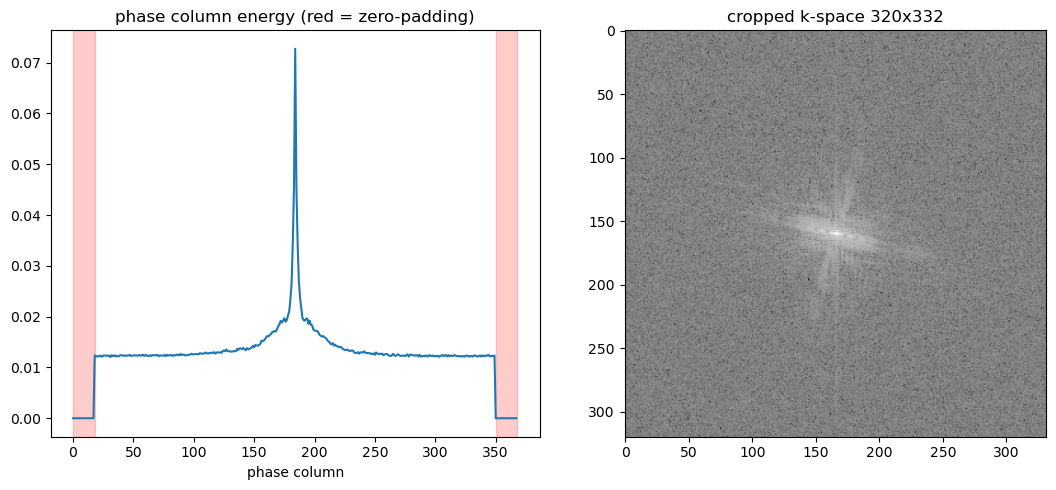

In [3]:
colE = np.abs(k1).sum((0,1)); nz = np.where(colE>0)[0]
k2 = k1[:, :, nz.min():nz.max()+1]                      # (15,320,332)
print(f'phase non-zero {nz.min()}..{nz.max()} -> {k2.shape[-1]} (removed {368-k2.shape[-1]} zero cols)')
fig, ax = plt.subplots(1,2,figsize=(11,5))
ax[0].plot(colE); ax[0].axvspan(0,nz.min(),color='r',alpha=0.2); ax[0].axvspan(nz.max()+1,368,color='r',alpha=0.2)
ax[0].set_title('phase column energy (red = zero-padding)'); ax[0].set_xlabel('phase column')
ax[1].imshow(klog(k2[7]), cmap='gray', aspect='equal'); ax[1].set_title(f'cropped k-space 320x{k2.shape[-1]}')
plt.tight_layout(); plt.show()

## 3단계 — recon = **SENSE GT** (320×332)
감도맵은 **full readout(640)** 에서 추정(물체가 끝에 안 닿아 artifact 없음) 후 readout을 320으로 crop.
그 맵으로 `Σ_c conj(S_c)·IFFT(k_c)` → **SENSE GT**.

Done.
sens (15, 320, 332)
SENSE GT (320, 332) complex64


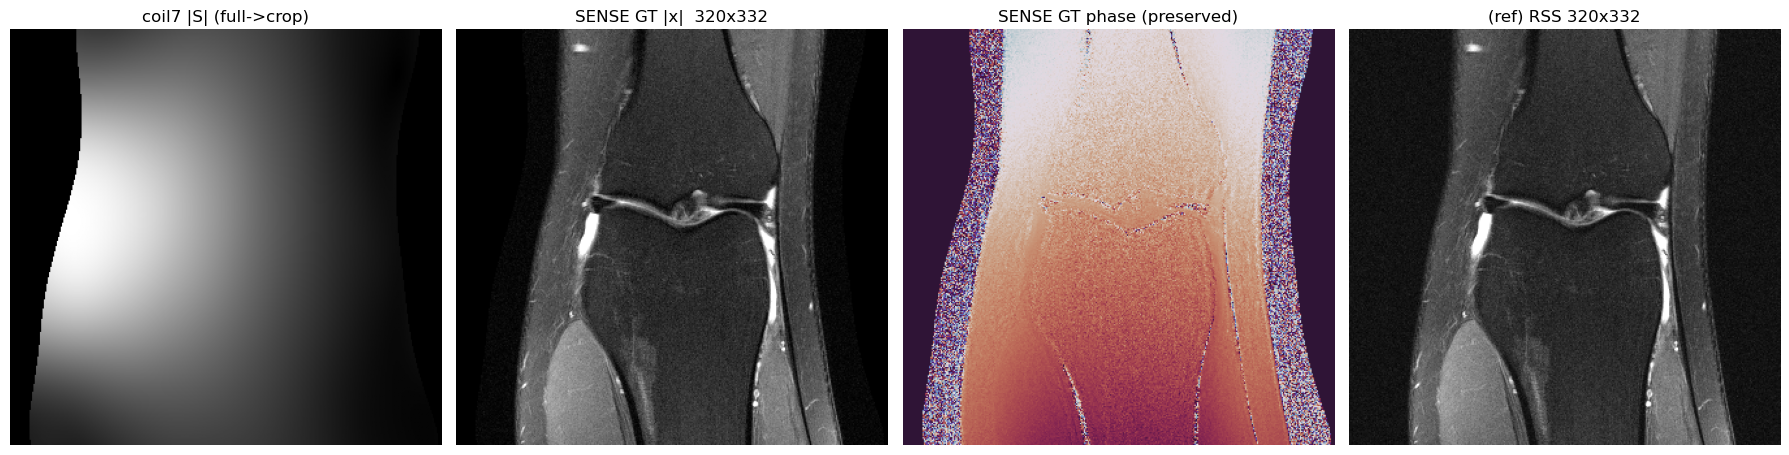

In [4]:
# --- sens: full readout에서 추정 -> readout crop (FOV-edge artifact 방지) ---
kraw_pc = kraw[:, :, nz.min():nz.max()+1]               # phase zero-pad 제거만 (15,640,332)
sens_full = espirit_sens_maps(kraw_pc)                  # ESPIRiT on full readout (15,640,332)
sens = sens_full[:, top:top+320, :]                     # readout crop -> (15,320,332)
print('sens', sens.shape)

gt_sense = sense_combine_np(k2, sens)                   # (320,332) complex  <-- GT
print('SENSE GT', gt_sense.shape, gt_sense.dtype)

fig, ax = plt.subplots(1,4,figsize=(18,5))
ax[0].imshow(np.abs(sens[7]), cmap='gray'); ax[0].set_title('coil7 |S| (full->crop)'); ax[0].axis('off')
ax[1].imshow(np.abs(gt_sense), cmap='gray', vmax=0.6*np.abs(gt_sense).max()); ax[1].set_title('SENSE GT |x|  320x332'); ax[1].axis('off')
ax[2].imshow(np.angle(gt_sense), cmap='twilight'); ax[2].set_title('SENSE GT phase (preserved)'); ax[2].axis('off')
ax[3].imshow(rss_np(k2), cmap='gray', vmax=0.6*rss_np(k2).max()); ax[3].set_title('(ref) RSS 320x332'); ax[3].axis('off')
plt.tight_layout(); plt.show()

## 요약
- **GT = SENSE 결합 (320×332 복소, 위상 포함)** — RSS 아님
- readout: oversampling만 제거(640→320) / phase: zero-padding만 제거(368→332, 실데이터 보존)
- 감도맵은 full readout 추정 후 crop → 아래쪽 검은 띠 없음
- 공식 RSS(320×320)와 크기·도메인이 달라 **별개 GT**